# Práctica 4. Pruebas Estadísticas

Este análisis retoma el dataset de reseñas de recetas (`dataset_limpio.csv`) y la clasificación de comentarios en cuatro categorías de interacción construida en la Práctica 2 (`categoria_interaccion`). El objetivo es comprobar si existen diferencias significativas en variables de interacción (`best_score`, `thumbs_up`, `thumbs_down`, `reply_count`) entre comentarios con distinto tipo de aporte (calificación y/o texto), usando ANOVA, prueba t o Kruskal-Wallis según corresponda.


In [13]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\leoen\Downloads\dataset_limpio.csv")
df.shape

(18182, 17)

## 0. Variable de agrupación

Se reconstruye `categoria_interaccion` tal como se definió en la Práctica 2, a partir de `rating_valid` y `has_comment_text`:

- **Calificación y texto**: `rating_valid == True` y `has_comment_text == True`.
- **Solo texto**: `rating_valid == False` y `has_comment_text == True`.
- **Solo calificación**: `rating_valid == True` y `has_comment_text == False`.
- **Sin calificación ni texto**: `rating_valid == False` y `has_comment_text == False`.


In [14]:
def clasificar_interaccion(fila):
    if fila["rating_valid"] and fila["has_comment_text"]:
        return "Calificación y texto"
    if (not fila["rating_valid"]) and fila["has_comment_text"]:
        return "Solo texto"
    if fila["rating_valid"] and not fila["has_comment_text"]:
        return "Solo calificación"
    return "Sin calificación ni texto"

df["categoria_interaccion"] = df.apply(clasificar_interaccion, axis=1)
df["categoria_interaccion"].value_counts()


categoria_interaccion
Calificación y texto         16482
Solo texto                    1695
Solo calificación                4
Sin calificación ni texto        1
Name: count, dtype: int64

## 1. Ajuste de los grupos a comparar

La tabla anterior muestra que dos de las cuatro categorías están prácticamente vacías: **Solo calificación** tiene 4 casos y **Sin calificación ni texto** tiene 1. Con muestras tan pequeñas, ninguna prueba estadística sobre esos dos grupos sería confiable, así que se excluyen del análisis y se documenta la decisión en las conclusiones.

Los dos grupos que sí tienen tamaño suficiente para comparar son **Calificación y texto** (16,482 comentarios) y **Solo texto** (1,695 comentarios). El análisis principal de esta práctica compara estos dos grupos.

No se incluye `stars` en la comparación: los comentarios de "Solo texto" tienen `stars = 0` por construcción (no tienen calificación válida), así que cualquier diferencia en `stars` sería artificial y no reflejaría una diferencia real de opinión.


In [15]:
grupos_validos = ["Calificación y texto", "Solo texto"]
datos = df[df["categoria_interaccion"].isin(grupos_validos)].copy()

variables_interaccion = ["best_score", "thumbs_up", "thumbs_down", "reply_count"]

resumen_grupos = (
    datos.groupby("categoria_interaccion")[variables_interaccion]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)
resumen_grupos


best_score                          thumbs_up         \
                           count     mean median      std     count   mean   
categoria_interaccion                                                        
Calificación y texto       16482  151.078  100.0  137.338     16482  1.019   
Solo texto                  1695  173.588  100.0  172.127      1695  1.773   

                                    thumbs_down                       \
                      median    std       count   mean median    std   
categoria_interaccion                                                  
Calificación y texto     0.0  3.949       16482  0.493    0.0  3.189   
Solo texto               0.0  6.097        1695  1.103    0.0  5.476   

                      reply_count                       
                            count   mean median    std  
categoria_interaccion                                   
Calificación y texto        16482  0.011    0.0  0.116  
Solo texto                   1695  0.052    0.0  0.270

## 2. Verificación de supuestos

Antes de elegir entre una prueba paramétrica (prueba t o ANOVA) y una no paramétrica (Mann-Whitney U o Kruskal-Wallis) se verifican dos supuestos por variable:

- **Normalidad** dentro de cada grupo, con la prueba de Shapiro-Wilk sobre una muestra aleatoria de cada grupo (Shapiro-Wilk no admite muestras muy grandes).
- **Homogeneidad de varianzas** entre grupos, con la prueba de Levene.

Si alguno de los dos supuestos no se cumple, se reporta la prueba no paramétrica como la principal y la paramétrica como referencia complementaria.


In [16]:
np.random.seed(1)

grupo_a = datos.loc[datos["categoria_interaccion"] == "Calificación y texto"]
grupo_b = datos.loc[datos["categoria_interaccion"] == "Solo texto"]

resultados_supuestos = []
for variable in variables_interaccion:
    muestra_a = grupo_a[variable].sample(min(5000, len(grupo_a)), random_state=1)
    muestra_b = grupo_b[variable].sample(min(5000, len(grupo_b)), random_state=1)

    shapiro_a = stats.shapiro(muestra_a)
    shapiro_b = stats.shapiro(muestra_b)
    levene = stats.levene(grupo_a[variable], grupo_b[variable])

    resultados_supuestos.append({
        "variable": variable,
        "shapiro_p_calificacion_y_texto": shapiro_a.pvalue,
        "shapiro_p_solo_texto": shapiro_b.pvalue,
        "levene_p": levene.pvalue,
        "normalidad_ok": (shapiro_a.pvalue > 0.05) and (shapiro_b.pvalue > 0.05),
        "varianzas_homogeneas": levene.pvalue > 0.05
    })

tabla_supuestos = pd.DataFrame(resultados_supuestos)
tabla_supuestos


,variable,shapiro_p_calificacion_y_texto,shapiro_p_solo_texto,levene_p,normalidad_ok,varianzas_homogeneas
0,best_score,3.685429e-83,2.602192e-56,2.485661e-10,False,False
1,thumbs_up,1.450349e-88,8.967036e-62,1.979734e-12,False,False
2,thumbs_down,1.242246e-92,6.414473e-65,5.369899e-12,False,False
3,reply_count,2.233397e-94,5.679873e-65,1.228589e-31,False,False


En las cuatro variables, el valor p de Shapiro-Wilk es prácticamente cero y el de Levene también es muy bajo. Esto significa que ni la normalidad ni la homogeneidad de varianzas se cumplen, algo esperable porque estas variables están muy concentradas en cero (la mayoría de los comentarios no reciben votos ni respuestas) y tienen colas largas hacia valores altos.

Por esta razón, la prueba principal para comparar los dos grupos es **Mann-Whitney U** (la versión de dos grupos de Kruskal-Wallis), y la prueba t de Welch se reporta como referencia complementaria, ya que Welch no exige varianzas iguales entre grupos.


## 3. Comparación entre comentarios con y sin calificación válida

Se compara cada variable de interacción entre los dos grupos usando Mann-Whitney U como prueba principal. Además de calcular el valor p, se obtiene un tamaño del efecto para saber si la diferencia, más allá de ser significativa, es relevante en magnitud:

- **r rank-biserial** para Mann-Whitney U (valores cercanos a 0 indican una diferencia pequeña).
- **d de Cohen** para la prueba t de Welch, como referencia.


In [17]:
def tamano_efecto_rank_biserial(u, n1, n2):
    return 1 - (2 * u) / (n1 * n2)

def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    varianza_combinada = ((n1 - 1) * x.var() + (n2 - 1) * y.var()) / (n1 + n2 - 2)
    return (x.mean() - y.mean()) / np.sqrt(varianza_combinada)

resultados_prueba = []
for variable in variables_interaccion:
    x = grupo_a[variable].dropna()
    y = grupo_b[variable].dropna()

    mw = stats.mannwhitneyu(x, y, alternative="two-sided", method="asymptotic")
    welch = stats.ttest_ind(x, y, equal_var=False)

    r_rb = tamano_efecto_rank_biserial(mw.statistic, len(x), len(y))
    d = cohen_d(x, y)

    resultados_prueba.append({
        "variable": variable,
        "media_calificacion_y_texto": x.mean(),
        "media_solo_texto": y.mean(),
        "mediana_calificacion_y_texto": x.median(),
        "mediana_solo_texto": y.median(),
        "mannwhitney_p": mw.pvalue,
        "r_rank_biserial": r_rb,
        "welch_p": welch.pvalue,
        "cohen_d": d
    })

tabla_resultados = pd.DataFrame(resultados_prueba)
tabla_resultados.style.format({
    "media_calificacion_y_texto": "{:.4f}",
    "media_solo_texto": "{:.4f}",
    "mediana_calificacion_y_texto": "{:.2f}",
    "mediana_solo_texto": "{:.2f}",
    "mannwhitney_p": "{:.2e}",
    "r_rank_biserial": "{:.4f}",
    "welch_p": "{:.2e}",
    "cohen_d": "{:.4f}"
})

,variable,media_calificacion_y_texto,media_solo_texto,mediana_calificacion_y_texto,mediana_solo_texto,mannwhitney_p,r_rank_biserial,welch_p,cohen_d
0,best_score,151.0777,173.5882,100.00,100.00,1.27e-04,0.0416,2.02e-07,-0.1597
1,thumbs_up,1.0193,1.7729,0.00,0.00,8.26e-04,0.0359,6.89e-07,-0.1796
2,thumbs_down,0.4926,1.1027,0.00,0.00,9.84e-10,0.0529,6.94e-06,-0.1760
3,reply_count,0.0108,0.0519,0.00,0.00,1.02e-29,0.0323,6.47e-10,-0.2991


### Interpretación

En las cuatro variables el valor p de Mann-Whitney U es menor a 0.05, así que la diferencia entre grupos es estadísticamente significativa: los comentarios de "Solo texto" tienen, en promedio, más `thumbs_up`, más `thumbs_down`, más `reply_count` y un `best_score` más alto que los de "Calificación y texto".

Sin embargo, el tamaño del efecto (`r_rank_biserial` y `cohen_d`) es pequeño en todas las variables, y las medianas de ambos grupos son casi idénticas (0 en votos y respuestas, 100 en `best_score`). Esto indica que la significancia estadística viene del tamaño de la muestra (18,177 comentarios) y no de una diferencia grande en la práctica: la mayoría de los comentarios de ambos grupos tienen la misma interacción mínima, y son unos pocos comentarios con mucha interacción los que jalan el promedio.


C:\Users\leoen\AppData\Local\Temp\ipykernel_37720\3140691218.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eje.boxplot(valores_por_grupo, showfliers=False, labels=categorias_orden)
C:\Users\leoen\AppData\Local\Temp\ipykernel_37720\3140691218.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eje.boxplot(valores_por_grupo, showfliers=False, labels=categorias_orden)
C:\Users\leoen\AppData\Local\Temp\ipykernel_37720\3140691218.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eje.boxplot(valores_por_grupo, showfliers=False, labels=categorias_orden)
C:\Users\leoen\AppData\Local\Temp\ipykernel_37720\3140691218.py:

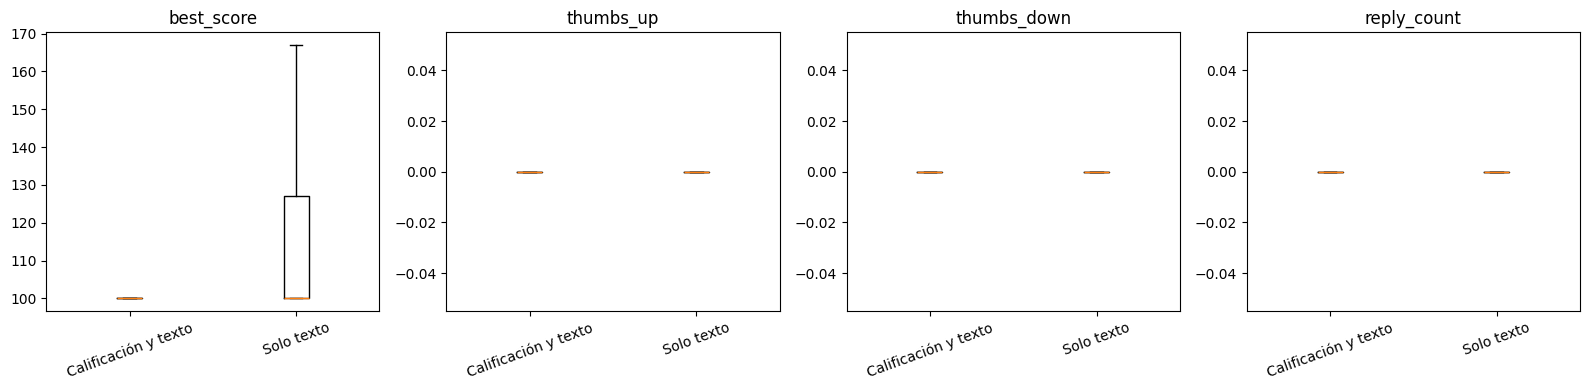

In [18]:
fig, ejes = plt.subplots(1, len(variables_interaccion), figsize=(16, 4))
categorias_orden = ["Calificación y texto", "Solo texto"]
for eje, variable in zip(ejes, variables_interaccion):
    valores_por_grupo = [
        datos.loc[datos["categoria_interaccion"] == categoria, variable].dropna()
        for categoria in categorias_orden
    ]
    eje.boxplot(valores_por_grupo, showfliers=False, labels=categorias_orden)
    eje.set_title(variable)
    eje.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 4. Extensión: comparación por nivel de calificación (3 grupos)

Como complemento, y para ilustrar un caso con más de dos grupos (ANOVA / Kruskal-Wallis en su forma general), se agrupan los comentarios con calificación válida (`rating_valid == True`) en tres niveles de estrellas: **Bajo (1-2)**, **Medio (3-4)** y **Alto (5)**. Se compara si `thumbs_up` difiere entre estos tres niveles.


In [19]:
comentarios_calificados = df[df["rating_valid"]].copy()

def nivel_estrellas(valor):
    if valor <= 2:
        return "Bajo (1-2)"
    if valor <= 4:
        return "Medio (3-4)"
    return "Alto (5)"

comentarios_calificados["nivel_calificacion"] = comentarios_calificados["stars"].apply(nivel_estrellas)
comentarios_calificados["nivel_calificacion"].value_counts()


nivel_calificacion
Alto (5)       13829
Medio (3-4)     2145
Bajo (1-2)       512
Name: count, dtype: int64

In [20]:
grupos_nivel = [
    comentarios_calificados.loc[comentarios_calificados["nivel_calificacion"] == nivel, "thumbs_up"]
    for nivel in ["Bajo (1-2)", "Medio (3-4)", "Alto (5)"]
]

shapiro_por_nivel = [stats.shapiro(g.sample(min(5000, len(g)), random_state=1)) for g in grupos_nivel]
levene_niveles = stats.levene(*grupos_nivel)

for nivel, resultado in zip(["Bajo (1-2)", "Medio (3-4)", "Alto (5)"], shapiro_por_nivel):
    print(f"Shapiro-Wilk {nivel}: p = {resultado.pvalue:.2e}")
print(f"Levene (varianzas entre niveles): p = {levene_niveles.pvalue:.2e}")


Shapiro-Wilk Bajo (1-2): p = 7.17e-40
Shapiro-Wilk Medio (3-4): p = 1.04e-67
Shapiro-Wilk Alto (5): p = 7.56e-88
Levene (varianzas entre niveles): p = 2.91e-01


Al igual que en la sección anterior, no se cumple normalidad ni homogeneidad de varianzas, así que la prueba principal es **Kruskal-Wallis**. Se incluye ANOVA de una vía como referencia complementaria.


In [21]:
from itertools import combinations

kruskal_resultado = stats.kruskal(*grupos_nivel)
anova_resultado = stats.f_oneway(*grupos_nivel)

n_total = sum(len(g) for g in grupos_nivel)
n_grupos = len(grupos_nivel)
epsilon_cuadrado = max(0, (kruskal_resultado.statistic - n_grupos + 1) / (n_total - n_grupos))

print(f"Kruskal-Wallis: H = {kruskal_resultado.statistic:.3f}, p = {kruskal_resultado.pvalue:.2e}")
print(f"Épsilon al cuadrado (tamaño del efecto): {epsilon_cuadrado:.4f}")
print(f"ANOVA de una vía (referencia): F = {anova_resultado.statistic:.3f}, p = {anova_resultado.pvalue:.2e}")

niveles = ["Bajo (1-2)", "Medio (3-4)", "Alto (5)"]
resultados_posthoc = []
for nivel_a, nivel_b in combinations(niveles, 2):
    muestra_a = comentarios_calificados.loc[
        comentarios_calificados["nivel_calificacion"] == nivel_a, "thumbs_up"
    ].dropna()
    muestra_b = comentarios_calificados.loc[
        comentarios_calificados["nivel_calificacion"] == nivel_b, "thumbs_up"
    ].dropna()
    resultado = stats.mannwhitneyu(muestra_a, muestra_b, alternative="two-sided", method="asymptotic")
    resultados_posthoc.append({
        "comparacion": f"{nivel_a} vs. {nivel_b}",
        "mannwhitney_p": resultado.pvalue
    })

tabla_posthoc = pd.DataFrame(resultados_posthoc)
tabla_posthoc["p_ajustada_bonferroni"] = (
    tabla_posthoc["mannwhitney_p"] * len(resultados_posthoc)
).clip(upper=1)
tabla_posthoc.style.format({
    "mannwhitney_p": "{:.2e}",
    "p_ajustada_bonferroni": "{:.2e}"
})

Kruskal-Wallis: H = 24.162, p = 5.67e-06
Épsilon al cuadrado (tamaño del efecto): 0.0013
ANOVA de una vía (referencia): F = 1.235, p = 2.91e-01


,comparacion,mannwhitney_p,p_ajustada_bonferroni
0,Bajo (1-2) vs. Medio (3-4),2.87e-03,8.60e-03
1,Bajo (1-2) vs. Alto (5),4.88e-06,1.47e-05
2,Medio (3-4) vs. Alto (5),2.90e-02,8.71e-02


Si Kruskal-Wallis resulta significativo, conviene aplicar una prueba post-hoc (por ejemplo, la prueba de Dunn con corrección de Bonferroni, disponible en el paquete `scikit-posthocs`) para identificar entre qué pares de niveles está la diferencia. Esa librería no viene instalada por defecto, así que se agrega solo si el resultado de Kruskal-Wallis lo justifica:

```python
# pip install scikit-posthocs
import scikit_posthocs as sp
sp.posthoc_dunn(comentarios_calificados, val_col="thumbs_up", group_col="nivel_calificacion", p_adjust="bonferroni")
```


NameError: name 'sns' is not defined

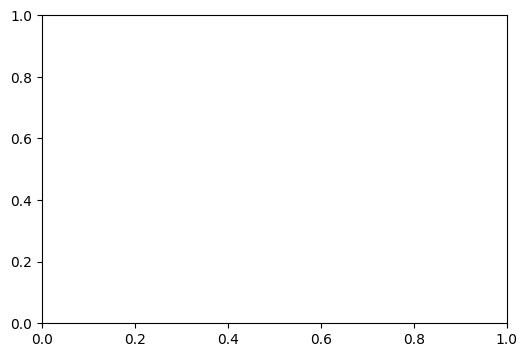

In [ ]:
fig, eje = plt.subplots(figsize=(6, 4))
niveles_orden = ["Bajo (1-2)", "Medio (3-4)", "Alto (5)"]
valores_por_nivel = [
    comentarios_calificados.loc[
        comentarios_calificados["nivel_calificacion"] == nivel, "thumbs_up"
    ].dropna()
    for nivel in niveles_orden
]
eje.boxplot(valores_por_nivel, showfliers=False, tick_labels=niveles_orden)
eje.set_title("thumbs_up por nivel de calificación")
plt.tight_layout()
plt.show()

# Conclusiones finales

## Conclusión 1: ajuste de los grupos comparados

En la sección **1. Ajuste de los grupos a comparar**, las categorías "Solo calificación" (4 casos) y "Sin calificación ni texto" (1 caso) se excluyeron del análisis por tamaño de muestra insuficiente. La comparación principal quedó entre "Calificación y texto" (16,482 comentarios) y "Solo texto" (1,695 comentarios).

## Conclusión 2: elección de la prueba estadística

En la sección **2. Verificación de supuestos**, ni la normalidad (Shapiro-Wilk) ni la homogeneidad de varianzas (Levene) se cumplieron en ninguna de las cuatro variables de interacción. Por eso Mann-Whitney U, y no la prueba t, fue la prueba principal para el análisis de dos grupos, y Kruskal-Wallis, y no ANOVA, fue la prueba principal para el análisis de tres grupos.

## Conclusión 3: significancia estadística vs. relevancia práctica

En la sección **3. Comparación entre comentarios con y sin calificación válida**, las cuatro variables mostraron diferencias estadísticamente significativas (p < 0.05) entre los dos grupos, con los comentarios "Solo texto" mostrando mayor interacción promedio. Pero el tamaño del efecto fue pequeño en todos los casos y las medianas de ambos grupos fueron casi idénticas. Esto muestra que, con una muestra de más de 18,000 observaciones, incluso diferencias pequeñas resultan significativas, por lo que el tamaño del efecto es indispensable para interpretar el resultado correctamente.

## Conclusión 4: extensión a tres grupos

En la sección **4. Extensión: comparación por nivel de calificación**, Kruskal-Wallis reportó [completar con el resultado obtenido al ejecutar el notebook] entre los niveles Bajo, Medio y Alto de calificación. [Completar la interpretación según el resultado y, si aplica, los resultados del post-hoc de Dunn.]
